# Comparação de Modelos — DeepSearch

Este notebook treina **Random Forest** e **Decision Tree** com o mesmo pipeline (Holdout 80/20 + RandomizedSearchCV + KFold 5-fold) e compara seus desempenhos por meio de visualizações.

**Modelos avaliados:** Random Forest · Decision Tree  
**Métricas:** R², MAE, RMSE, CV R² médio

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, KFold, learning_curve
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Carregamento dos Dados

In [2]:
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    cwd = Path.cwd()
    BASE_DIR = cwd / "notebooks" if (cwd / "notebooks").exists() else cwd

DADOS_DIR = str((BASE_DIR / ".." / "projeto" / "dados").resolve())
if DADOS_DIR not in sys.path:
    sys.path.insert(0, DADOS_DIR)

from heuristicas import extract_features, compute_heuristic_score, DATASET_PATH

df = pd.read_csv(DATASET_PATH, encoding="latin-1")

rename = {}
for col in df.columns:
    if "vel da mar" in col.lower() or "nivel" in col.lower():
        rename[col] = "Nível da maré"
    elif "temperatura do mar" in col.lower():
        rename[col] = "Temperatura do mar (°C)"
df.rename(columns=rename, inplace=True)

df["risk_score"] = df.apply(compute_heuristic_score, axis=1)
X, _ = extract_features(df)
y = df["risk_score"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Treino : {len(X_train)} amostras")
print(f"Teste  : {len(X_test)} amostras")

Treino : 2048 amostras
Teste  : 512 amostras


## 2. Treinamento dos Modelos

Ambos os modelos usam o mesmo pipeline: **RandomizedSearchCV (20 iterações)** com **KFold (5 folds)** sobre o conjunto de treino. O conjunto de teste só é tocado na avaliação final.

In [3]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Random Forest ---
print("Treinando Random Forest...")
rf_params = {
    "n_estimators": [100, 150, 200, 300],
    "max_depth": [8, 10, 12, 15, None],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params, n_iter=20, cv=kfold, scoring="r2", random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
print(f"  Melhores params: {rf_search.best_params_}")

# --- Decision Tree ---
print("Treinando Decision Tree...")
dt_params = {
    "max_depth": [3, 5, 8, 10, 12, 15, None],
    "min_samples_leaf": [1, 2, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2", None],
}
dt_search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params, n_iter=20, cv=kfold, scoring="r2", random_state=42, n_jobs=-1
)
dt_search.fit(X_train, y_train)
dt_best = dt_search.best_estimator_
print(f"  Melhores params: {dt_search.best_params_}")

# --- Coleta de métricas ---
def get_metrics(model, search, X_tr, y_tr, X_te, y_te, label):
    y_pred    = model.predict(X_te)
    y_pred_tr = model.predict(X_tr)
    return {
        "Modelo":       label,
        "CV R² médio":  round(search.best_score_, 4),
        "Train R²":     round(r2_score(y_tr, y_pred_tr), 4),
        "Test R²":      round(r2_score(y_te, y_pred), 4),
        "Test MAE":     round(mean_absolute_error(y_te, y_pred), 4),
        "Test RMSE":    round(np.sqrt(mean_squared_error(y_te, y_pred)), 4),
    }

rf_m = get_metrics(rf_best, rf_search, X_train, y_train, X_test, y_test, "Random Forest")
dt_m = get_metrics(dt_best, dt_search, X_train, y_train, X_test, y_test, "Decision Tree")

df_comp = pd.DataFrame([rf_m, dt_m]).set_index("Modelo")
print("\nTabela comparativa:")
df_comp

Treinando Random Forest...
  Melhores params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Treinando Decision Tree...
  Melhores params: {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10}

Tabela comparativa:


,CV R² médio,Train R²,Test R²,Test MAE,Test RMSE
Modelo,,,,,
Random Forest,0.8373,0.9796,0.8691,0.0205,0.0274
Decision Tree,0.7910,0.9506,0.8238,0.0227,0.0318


## 3. Comparação de Métricas

Barras com **borda laranja** indicam o melhor resultado para cada métrica.

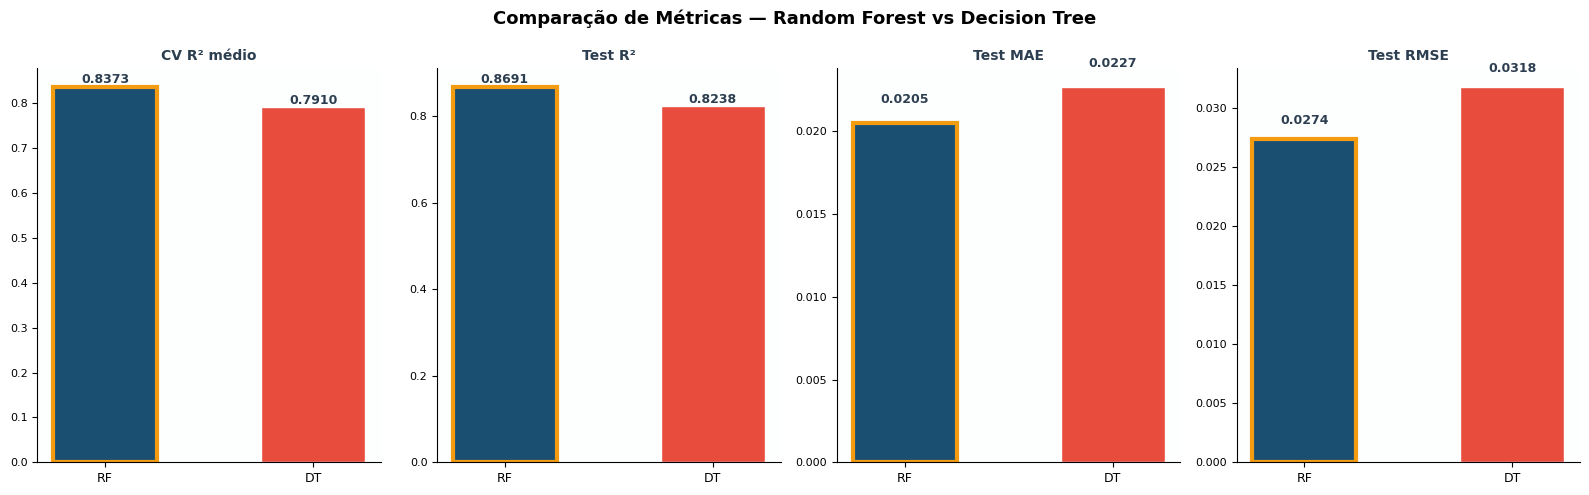

Borda laranja = melhor resultado para cada métrica


In [4]:
METRICAS     = ["CV R² médio", "Test R²", "Test MAE", "Test RMSE"]
MAIOR_MELHOR = {"CV R² médio": True, "Test R²": True, "Test MAE": False, "Test RMSE": False}
CORES        = ["#1B4F72", "#E74C3C"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Comparação de Métricas — Random Forest vs Decision Tree",
             fontsize=13, fontweight="bold")

for ax, metrica in zip(axes, METRICAS):
    valores = [rf_m[metrica], dt_m[metrica]]
    melhor_idx = np.argmax(valores) if MAIOR_MELHOR[metrica] else np.argmin(valores)

    bars = ax.bar(["Random Forest", "Decision Tree"], valores,
                  color=CORES, edgecolor="white", width=0.5)
    bars[melhor_idx].set_edgecolor("#F39C12")
    bars[melhor_idx].set_linewidth(3)

    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f"{val:.4f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color="#2C3E50")

    ax.set_title(metrica, fontsize=10, fontweight="bold", color="#2C3E50")
    ax.set_facecolor("#FDFEFE")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.set_xticklabels(["RF", "DT"], fontsize=9)

plt.tight_layout()
plt.show()
print("Borda laranja = melhor resultado para cada métrica")

## 4. Predito vs Real

Quanto mais os pontos se aproximam da linha diagonal tracejada (y = ŷ), melhor o modelo.

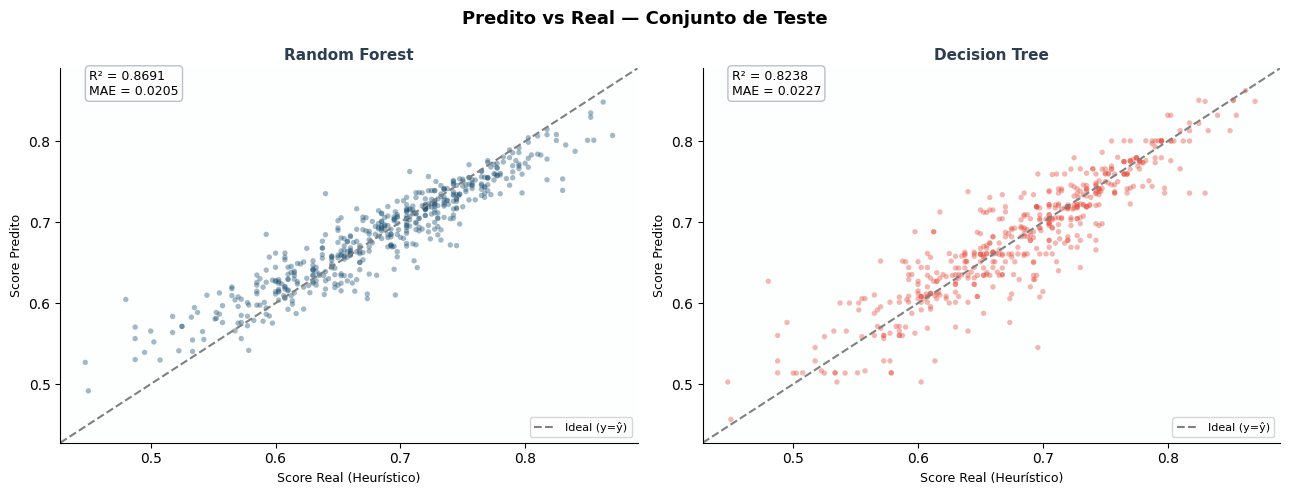

In [5]:
modelos_plot = [
    ("Random Forest", rf_best, "#1B4F72"),
    ("Decision Tree", dt_best, "#E74C3C"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Predito vs Real — Conjunto de Teste", fontsize=13, fontweight="bold")

for ax, (nome, modelo, cor) in zip(axes, modelos_plot):
    y_pred = modelo.predict(X_test)
    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color=cor, edgecolors="none")

    lims = [min(y_test.min(), y_pred.min()) - 0.02,
            max(y_test.max(), y_pred.max()) + 0.02]
    ax.plot(lims, lims, "--", color="gray", linewidth=1.5, label="Ideal (y=ŷ)")
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.text(0.05, 0.93, f"R² = {r2:.4f}\nMAE = {mae:.4f}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round", fc="white", ec="#AEB6BF", alpha=0.85))

    ax.set_title(nome, fontsize=11, fontweight="bold", color="#2C3E50")
    ax.set_xlabel("Score Real (Heurístico)", fontsize=9)
    ax.set_ylabel("Score Predito", fontsize=9)
    ax.set_facecolor("#FDFEFE")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Distribuição dos Resíduos

Resíduos próximos de zero e distribuídos simetricamente indicam um modelo bem calibrado.

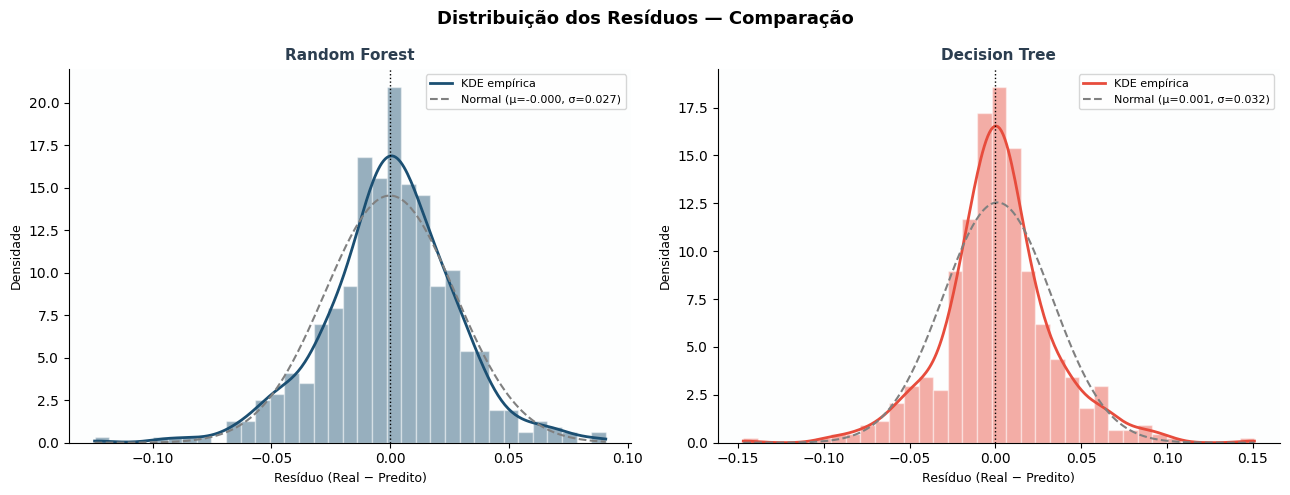

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Distribuição dos Resíduos — Comparação", fontsize=13, fontweight="bold")

for ax, (nome, modelo, cor) in zip(axes, modelos_plot):
    y_pred   = modelo.predict(X_test)
    residuos = y_test - y_pred
    mu, sigma = residuos.mean(), residuos.std()

    ax.hist(residuos, bins=35, density=True,
            color=cor, alpha=0.45, edgecolor="white")

    x_kde = np.linspace(residuos.min(), residuos.max(), 300)
    kde = stats.gaussian_kde(residuos)
    ax.plot(x_kde, kde(x_kde), color=cor, linewidth=2, label="KDE empírica")
    ax.plot(x_kde, stats.norm.pdf(x_kde, mu, sigma),
            "--", color="gray", linewidth=1.5,
            label=f"Normal (μ={mu:.3f}, σ={sigma:.3f})")

    ax.axvline(0, color="black", linewidth=1, linestyle=":")
    ax.set_title(nome, fontsize=11, fontweight="bold", color="#2C3E50")
    ax.set_xlabel("Resíduo (Real − Predito)", fontsize=9)
    ax.set_ylabel("Densidade", fontsize=9)
    ax.set_facecolor("#FDFEFE")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Curvas de Aprendizado

Mostram como o desempenho varia com o tamanho do conjunto de treino. Gap grande entre treino e validação indica **overfitting**; ambas baixas indicam **underfitting**.

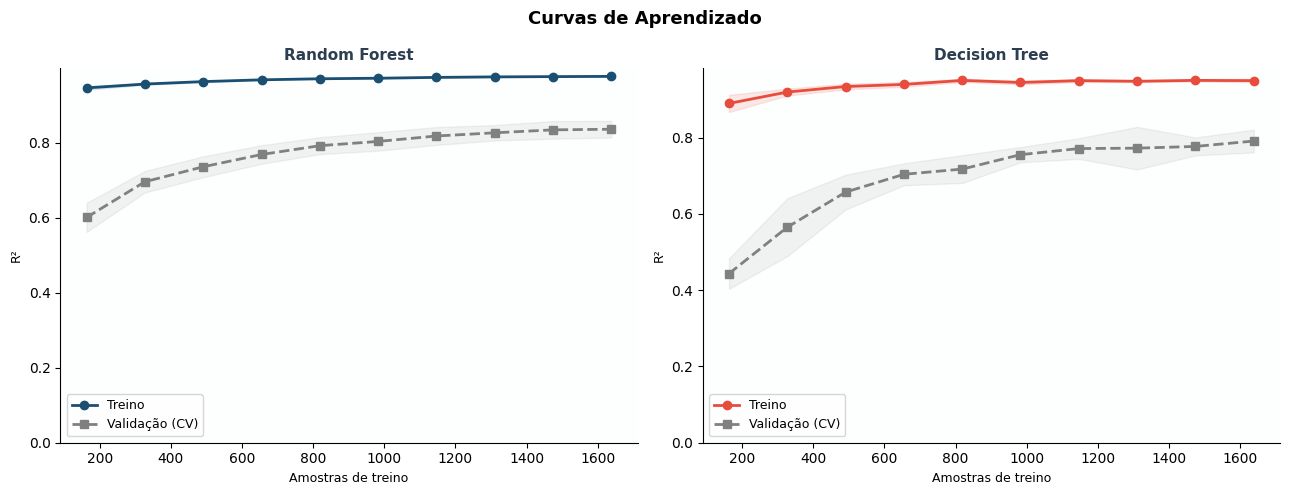

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Curvas de Aprendizado", fontsize=13, fontweight="bold")

for ax, (nome, modelo, cor) in zip(axes, modelos_plot):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X_train, y_train,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    va_mean, va_std = val_scores.mean(axis=1), val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, "o-", color=cor, linewidth=2, label="Treino")
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.12, color=cor)

    ax.plot(train_sizes, va_mean, "s--", color="gray", linewidth=2, label="Validação (CV)")
    ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std,
                    alpha=0.10, color="gray")

    ax.set_title(nome, fontsize=11, fontweight="bold", color="#2C3E50")
    ax.set_xlabel("Amostras de treino", fontsize=9)
    ax.set_ylabel("R²", fontsize=9)
    ax.set_facecolor("#FDFEFE")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

## 7. Conclusão

In [8]:
print("=" * 55)
print("RESUMO COMPARATIVO")
print("=" * 55)
print(df_comp.to_string())
print()

vencedor_r2  = "Random Forest" if rf_m["Test R²"]  > dt_m["Test R²"]  else "Decision Tree"
vencedor_mae = "Random Forest" if rf_m["Test MAE"] < dt_m["Test MAE"] else "Decision Tree"

print(f"Melhor R²  (maior é melhor): {vencedor_r2}")
print(f"Melhor MAE (menor é melhor): {vencedor_mae}")
print()
print("Modelo selecionado para produção: Random Forest")
print("Justificativa: Random Forest é um ensemble que reduz overfitting")
print("via média de múltiplas árvores, resultando em maior estabilidade")
print("e generalização em comparação à Decision Tree isolada.")

RESUMO COMPARATIVO
               CV R² médio  Train R²  Test R²  Test MAE  Test RMSE
Modelo                                                            
Random Forest       0.8373    0.9796   0.8691    0.0205     0.0274
Decision Tree       0.7910    0.9506   0.8238    0.0227     0.0318

Melhor R²  (maior é melhor): Random Forest
Melhor MAE (menor é melhor): Random Forest

Modelo selecionado para produção: Random Forest
Justificativa: Random Forest é um ensemble que reduz overfitting
via média de múltiplas árvores, resultando em maior estabilidade
e generalização em comparação à Decision Tree isolada.
